In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import io
import numpy as np

## IO Server Log Analysis

In [3]:
INPUT_DIR=Path('/scratch/gb02/pc2687/cylc-run/am3-n640/work/19830101T0000Z/atmos_main/')

log_files = INPUT_DIR.glob('ioserver_log.*')

io_logs = []

for log_file in list(log_files):
    print (f' INFO : Opening {log_file.name}')

    data = pd.read_csv(log_file,
                    sep='\s+',
                    header=None,
                    names=['time',log_file.name,'change'])

    data.set_index('time',inplace=True)
    io_logs.append(data[log_file.name])

 INFO : Opening ioserver_log.00127
 INFO : Opening ioserver_log.00095
 INFO : Opening ioserver_log.00223
 INFO : Opening ioserver_log.00159
 INFO : Opening ioserver_log.00191
 INFO : Opening ioserver_log.00063
 INFO : Opening ioserver_log.00255
 INFO : Opening ioserver_log.00031


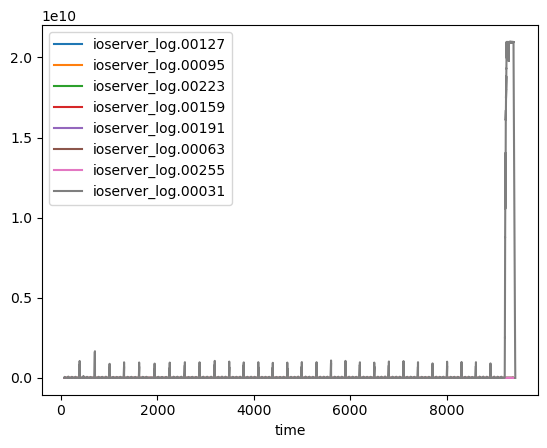

In [4]:
fig,ax = plt.subplots(1,1)
for data in io_logs:
    data.plot(ax=ax)
plt.legend()

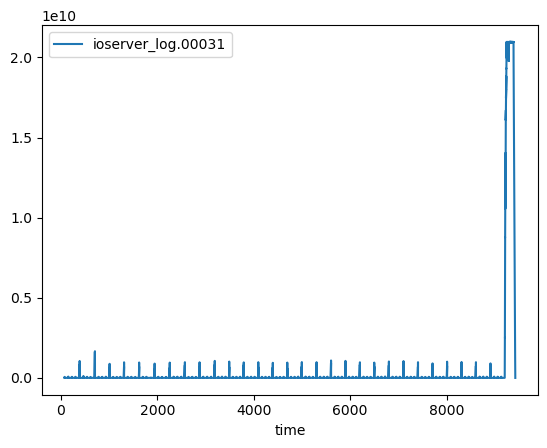

In [5]:
fig,ax = plt.subplots(1,1)
for data in io_logs:
    if data.max() > 1e10:
        data.plot(ax=ax)
plt.legend()

## Timestep log analysis

In [9]:
PE_DIR=Path('/scratch/gb02/pc2687/cylc-run/am3-n640/work/19830101T0000Z/atmos_main/pe_output/')
pe0_file = PE_DIR / 'n640.fort6.pe0000'

csv_start = io.StringIO()
csv_elapsed = io.StringIO()
csv_start_lines = []
csv_elapsed_lines = []

with open(pe0_file, 'r') as fp:
    for index, line in enumerate(fp):
        if 'Atm_Step: Info: Starting' in line:
            csv_start_lines.append(f'{line}')
        if 'Atm_Step: Info: timestep' in line:
            csv_elapsed_lines.append(f'{line}')

for line in csv_start_lines:
    csv_start.write(line)

for line in csv_elapsed_lines:
    csv_elapsed.write(line) 

In [10]:
csv_start.seek(0)
df_start = pd.read_csv(csv_start, header=None,sep='\s+')
df_start

,0,1,2,3,4,5,6,7,8
0,Atm_Step:,Info:,Starting,timestep,0,at,time=,76.085,seconds
1,Atm_Step:,Info:,Starting,timestep,1,at,time=,79.895,seconds
2,Atm_Step:,Info:,Starting,timestep,2,at,time=,85.615,seconds
3,Atm_Step:,Info:,Starting,timestep,3,at,time=,86.986,seconds
4,Atm_Step:,Info:,Starting,timestep,4,at,time=,88.342,seconds
...,...,...,...,...,...,...,...,...,...
4316,Atm_Step:,Info:,Starting,timestep,4316,at,time=,9196.623,seconds
4317,Atm_Step:,Info:,Starting,timestep,4317,at,time=,9197.954,seconds
4318,Atm_Step:,Info:,Starting,timestep,4318,at,time=,9199.269,seconds
4319,Atm_Step:,Info:,Starting,timestep,4319,at,time=,9200.573,seconds


In [11]:
csv_elapsed.seek(0)
df_elapsed = pd.read_csv(csv_elapsed, header=None,sep='\s+')
df_elapsed

,0,1,2,3,4,5,6
0,Atm_Step:,Info:,timestep,1,took,5.720,seconds
1,Atm_Step:,Info:,timestep,2,took,1.370,seconds
2,Atm_Step:,Info:,timestep,3,took,1.355,seconds
3,Atm_Step:,Info:,timestep,4,took,1.366,seconds
4,Atm_Step:,Info:,timestep,5,took,1.386,seconds
...,...,...,...,...,...,...,...
4315,Atm_Step:,Info:,timestep,4316,took,1.330,seconds
4316,Atm_Step:,Info:,timestep,4317,took,1.314,seconds
4317,Atm_Step:,Info:,timestep,4318,took,1.303,seconds
4318,Atm_Step:,Info:,timestep,4319,took,1.334,seconds


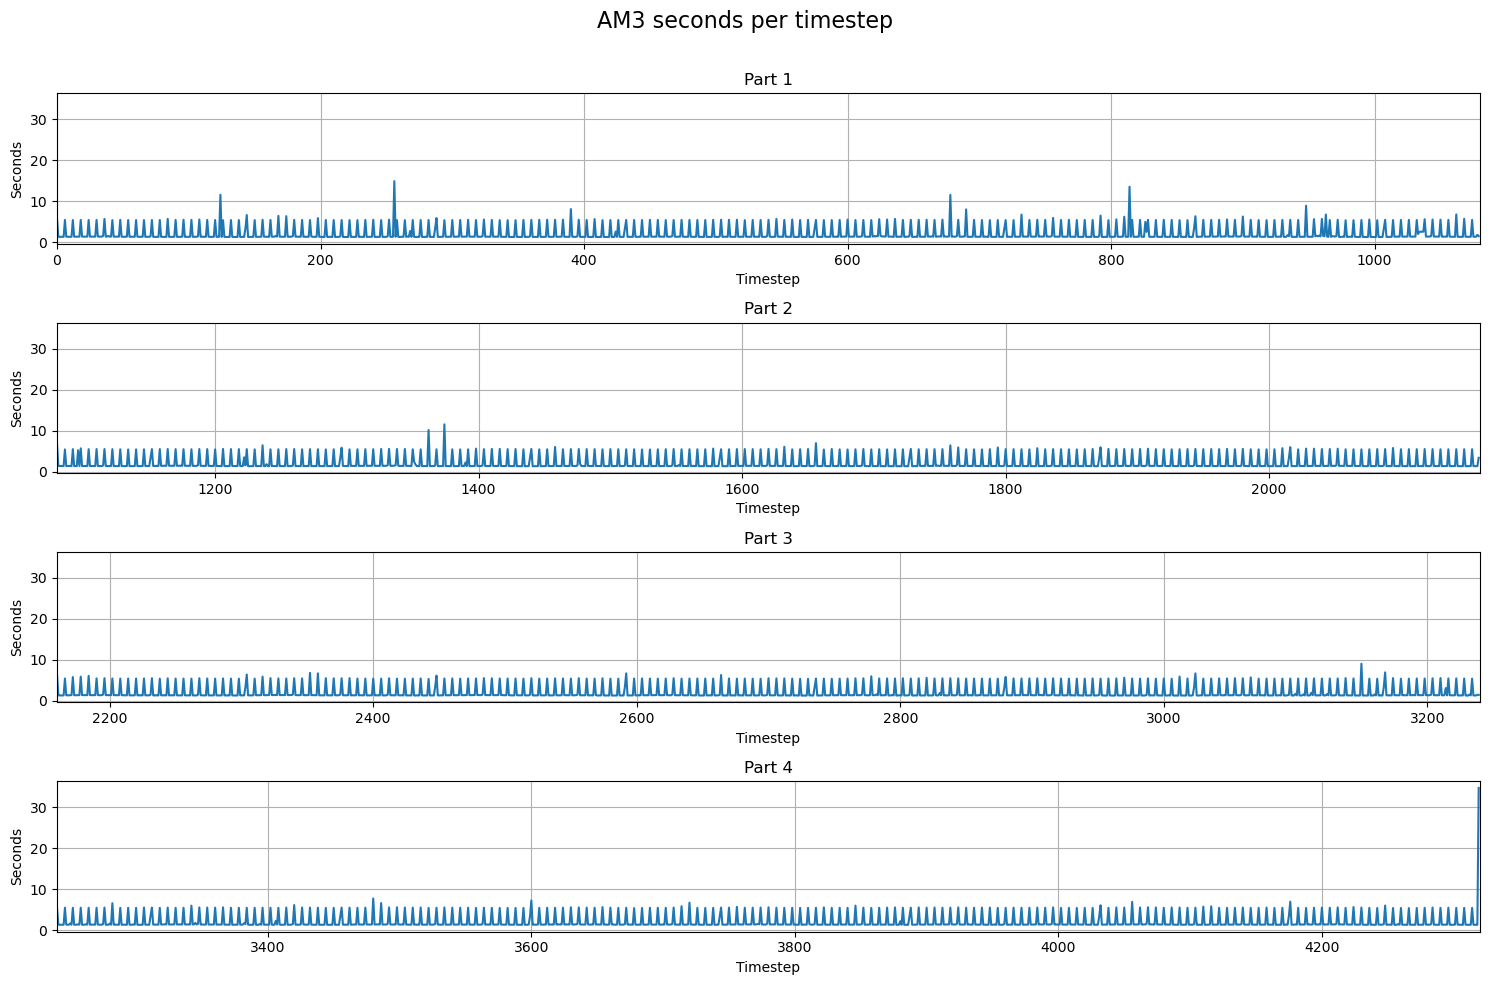

In [27]:
series = df_elapsed.iloc[:, 5]
n = len(series)
num_parts = 4
part_size = n // num_parts

fig, axes = plt.subplots(num_parts, 1, figsize=(15, 10), sharey=True)

for i, ax in enumerate(axes):
    start = i * part_size
    end = (i + 1) * part_size if i < num_parts - 1 else n
    segment = series.iloc[start:end]
    segment.plot(ax=ax, title=f"Part {i+1}", ylabel='Seconds')
    ax.set_xlabel('Timestep')
    ax.set_xlim(start, end)
    ax.grid(True)

plt.suptitle("AM3 seconds per timestep", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()